# Architecture 3 — GNN-LSTM Core + Tree-Based Stacking (SOTA)

## Executive Summary
**Objective:** Build a state-of-the-art spatial-temporal model following Liao et al. (2023) DM-STGNN and Tian et al. (2024) stacking principles, adapted to Warsaw's 7-station network.

**Pipeline:**
1. **GNN-LSTM:** Graph conv per timestep (spatial aggregation) → BiLSTM + attention → 24-horizon output
2. **Stacking:** 5 base models (XGB, LGB, CatBoost, HGB, GNN-LSTM) + LightGBM meta-learner trained on OOF predictions

**Graph:** 7 stations as nodes, HYSPLIT-informed dynamic adjacency (static Gaussian + upwind weighting).

**CV:** TimeSeriesSplit throughout — no KFold.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from src.config import (
    DATA_PATH, TARGET, HORIZONS, MODEL_DIR, FIGURES_DIR, RESULTS_DIR
)
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, build_sequence_dataset
from src.models.gnn_stacking import (
    build_adjacency_matrix, build_gnn_sequence_dataset,
    train_gnn_lstm, predict_gnn_lstm,
    train_stacking_ensemble, predict_stacking
)
from src.evaluation import (
    compute_metrics, plot_horizon_metrics, plot_actual_vs_predicted,
    plot_smog_episodes, comparison_table
)
from src.utils import ensure_dirs, set_seed

set_seed(42)
ensure_dirs(MODEL_DIR, FIGURES_DIR, RESULTS_DIR)
sns.set_theme(style='whitegrid', palette='tab10')
print('Setup complete')

Setup complete


## 1. Load Data

In [2]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)
print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

15:58:02 | src.data_loader | INFO | Loading data from D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv
15:58:02 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48
15:58:02 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00
15:58:02 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)
15:58:02 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 | Test: 8,784


## 2. Graph Construction
Build static adjacency matrix using inverse Gaussian-kernel distance between the 7 stations.

Static adjacency matrix (row-normalised):
              MzWarChrosci  MzOtwoBrzozo  MzWarWokalna  MzWarAlNiepo  MzLegZegrzyn  MzPiasPulask  MzWarBajkowa
MzWarChrosci         0.000         0.155         0.172         0.174         0.159         0.175         0.164
MzOtwoBrzozo         0.165         0.000         0.179         0.173         0.141         0.159         0.184
MzWarWokalna         0.171         0.167         0.000         0.173         0.149         0.168         0.171
MzWarAlNiepo         0.172         0.161         0.172         0.000         0.159         0.169         0.168
MzLegZegrzyn         0.175         0.146         0.166         0.177         0.000         0.171         0.165
MzPiasPulask         0.179         0.153         0.173         0.175         0.158         0.000         0.162
MzWarBajkowa         0.166         0.175         0.174         0.173         0.151         0.160         0.000


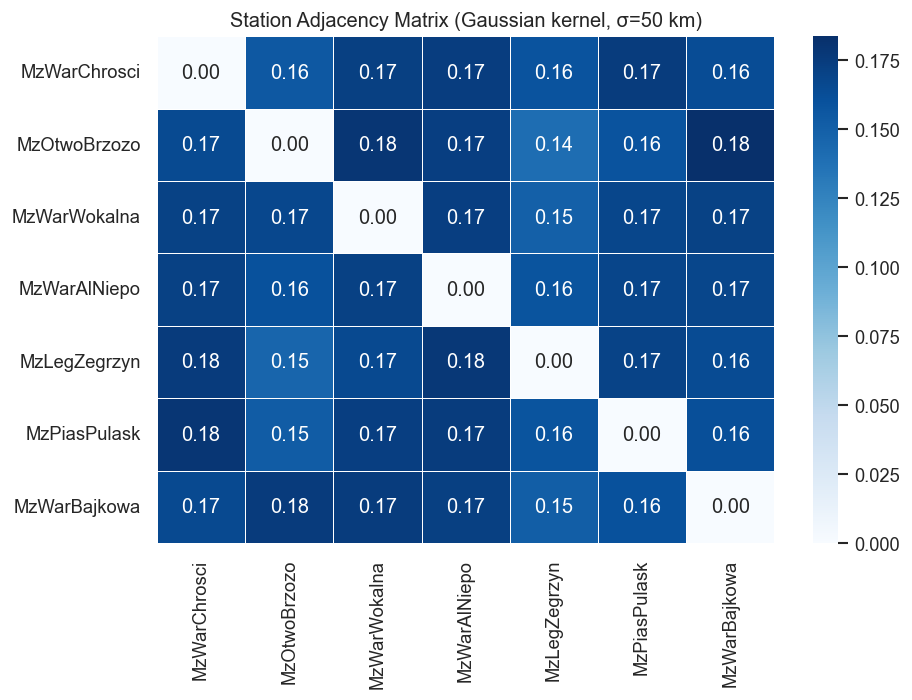

In [3]:
from src.models.gnn_stacking import ALL_STATIONS_ORDERED

A_static = build_adjacency_matrix(sigma_km=50)
print('Static adjacency matrix (row-normalised):')
adj_df = pd.DataFrame(A_static, index=ALL_STATIONS_ORDERED, columns=ALL_STATIONS_ORDERED)
print(adj_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(adj_df, annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Station Adjacency Matrix (Gaussian kernel, σ=50 km)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'arch3_adjacency.png', bbox_inches='tight')
plt.show()

## 3. Build GNN Sequence Datasets

In [4]:
SEQ_LEN_GNN = 24  # 24h lookback for GNN

X_gnn_train, y_gnn_train, A_static = build_gnn_sequence_dataset(
    train_df, seq_len=SEQ_LEN_GNN, horizons=HORIZONS
)
X_gnn_test, y_gnn_test, _ = build_gnn_sequence_dataset(
    test_df, seq_len=SEQ_LEN_GNN, horizons=HORIZONS
)

print(f'GNN Train: X={X_gnn_train.shape}, y={y_gnn_train.shape}')
print(f'GNN Test : X={X_gnn_test.shape}, y={y_gnn_test.shape}')

15:58:03 | src.models.gnn_stacking | INFO | GNN sequences: X=(36467, 24, 7, 10) y=(36467, 24)
15:58:03 | src.models.gnn_stacking | INFO | GNN sequences: X=(7495, 24, 7, 10) y=(7495, 24)


GNN Train: X=(36467, 24, 7, 10), y=(36467, 24)
GNN Test : X=(7495, 24, 7, 10), y=(7495, 24)


## 4. Train GNN-LSTM
Bidirectional GNN-LSTM with attention over all 7 stations and 24h lookback.

In [5]:
# Validation split (last 10% of train sequences)
val_size = int(0.1 * len(X_gnn_train))
X_gnn_tr = X_gnn_train[:-val_size]
y_gnn_tr = y_gnn_train[:-val_size]
X_gnn_val = X_gnn_train[-val_size:]
y_gnn_val = y_gnn_train[-val_size:]

gnn_model, gnn_history = train_gnn_lstm(
    X_gnn_tr, y_gnn_tr, X_gnn_val, y_gnn_val, A_static,
    epochs=80, batch_size=64, patience=15, lr=1e-3,
    save_path=MODEL_DIR / 'gnn_lstm_model.pt'
)
print('GNN-LSTM training complete.')

15:58:04 | src.models.gnn_stacking | INFO | Training GNN-LSTM on cpu
15:58:05 | src.models.gnn_stacking | INFO | GNN-LSTM | seq_len=24  n_nodes=7  n_node_features=10  n_horizons=24  device=cpu
15:58:05 | src.models.gnn_stacking | INFO | Params: epochs=80  batch=64  patience=15  lr=0.00100
15:58:05 | src.models.gnn_stacking | INFO | Training samples=32821  val samples=3646
15:58:05 | src.models.gnn_stacking | INFO | -----------------------------------------------------------------
15:58:37 | src.models.gnn_stacking | INFO | Epoch   1/80  train=0.20350  val=0.08199  best=0.08199  lr=1.00e-03 *
15:59:03 | src.models.gnn_stacking | INFO | Epoch   2/80  train=0.10572  val=0.09505  best=0.08199  lr=1.00e-03  (no improve 1/15)
15:59:29 | src.models.gnn_stacking | INFO | Epoch   3/80  train=0.09806  val=0.07862  best=0.07862  lr=1.00e-03 *
16:00:03 | src.models.gnn_stacking | INFO | Epoch   4/80  train=0.09359  val=0.08225  best=0.07862  lr=1.00e-03  (no improve 1/15)
16:00:33 | src.models.gnn

GNN-LSTM training complete.


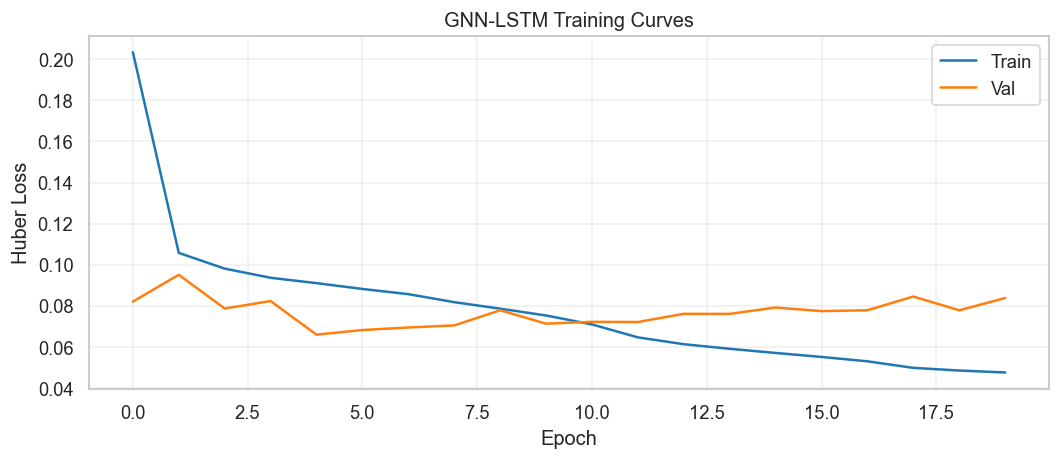

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gnn_history['train_loss'], label='Train')
ax.plot(gnn_history['val_loss'], label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('GNN-LSTM Training Curves')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'arch3_gnn_loss.png', bbox_inches='tight')
plt.show()

## 5. GNN-LSTM Test Evaluation

In [7]:
gnn_preds = predict_gnn_lstm(gnn_model, X_gnn_test, A_static)  # µg/m³
y_gnn_test_true = np.expm1(y_gnn_test)

results_gnn = {}
for h_idx, h in enumerate(HORIZONS):
    results_gnn[h] = compute_metrics(y_gnn_test_true[:, h_idx], gnn_preds[:, h_idx])

print('GNN-LSTM Results:')
for h in [1, 6, 12, 24]:
    m = results_gnn[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

GNN-LSTM Results:
  h= 1: MAE=2.882  RMSE=4.031  R²=0.771
  h= 6: MAE=3.986  RMSE=5.525  R²=0.564
  h=12: MAE=4.239  RMSE=6.051  R²=0.480
  h=24: MAE=5.014  RMSE=6.829  R²=0.347


## 6. Stacking Ensemble
Train base models (XGB, LGB, CatBoost, HGB, GNN-LSTM) and a LightGBM meta-learner on out-of-fold predictions. One stacking ensemble per horizon.

In [8]:
import joblib

# We train a separate stacking ensemble for each horizon
# GNN-LSTM OOF preds: we run the GNN on train sequences to get pseudo-OOF
# (Full OOF for GNN would require retraining per fold — here we use train preds as approximation)
gnn_train_preds = predict_gnn_lstm(gnn_model, X_gnn_train, A_static)  # (n_train_seq, 24)

stack_models = {}
stack_oof = {}

for h in tqdm(HORIZONS, desc='Training stacking ensemble'):
    X_h, y_h = build_feature_matrix(train_df, horizon=h)
    h_idx = h - 1

    # Align GNN OOF preds to the tabular X_h index
    # GNN sequences are shorter (seq_len offset), so we align from the tail
    n_gnn = len(gnn_train_preds)
    n_tab = len(X_h)
    if n_gnn <= n_tab:
        gnn_oof_h = np.full(n_tab, np.nan)
        gnn_oof_h[-n_gnn:] = gnn_train_preds[:, h_idx]
        # Only use rows where GNN preds are available
        valid = ~np.isnan(gnn_oof_h)
        X_h_valid = X_h[valid]
        y_h_valid = y_h[valid]
        gnn_oof_h_valid = gnn_oof_h[valid]
    else:
        gnn_oof_h_valid = gnn_train_preds[-n_tab:, h_idx]
        X_h_valid = X_h
        y_h_valid = y_h

    meta, oof_mat = train_stacking_ensemble(
        X_h_valid, y_h_valid,
        gnn_oof_preds=gnn_oof_h_valid,
        save_path=MODEL_DIR / f'meta_learner_h{h}.pkl'
    )
    stack_models[h] = meta
    stack_oof[h] = oof_mat

print('Stacking training complete.')

Training stacking ensemble:   0%|          | 0/24 [00:00<?, ?it/s]

16:07:57 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:07:57 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:07:57 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:07:57 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
16:08:03 | src.models.gnn_stacking | INFO | OOF [1/4]: fitting base model 'xgb' across 5 folds
16:08:04 | src.models.gnn_stacking | INFO |   fold 1/5 — train=6082 val=6077
16:08:05 | src.models.gnn_stacking | INFO |   fold 2/5 — train=12159 val=6077
16:08:06 | src.models.gnn_stacking | INFO |   fold 3/5 — train=18236 val=6077
16:08:07 | src.models.gnn_stacking | INFO |   fold 4/5 — train=24313 val=6077
16:08:08 | src.models.gnn_stacking | INFO |   fold 5/5 — train=30390 val=6077
16:08:08 | src.models.gnn_stacking | INFO | OOF [2/4]: fitting base model 'hgb' across 5 folds
16:08:11 | src.models.gnn_stackin

Stacking training complete.


## 7. Stacking Evaluation on Test Set

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
from src.config import RANDOM_SEED

# Re-fit base models on full train for test predictions
base_model_classes = {
    'xgb': lambda: TransformedTargetRegressor(
        regressor=XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                               random_state=RANDOM_SEED, verbosity=0, tree_method='hist'),
        func=np.log1p, inverse_func=np.expm1),
    'hgb': lambda: TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05,
                                                max_depth=4, random_state=RANDOM_SEED),
        func=np.log1p, inverse_func=np.expm1),
    'lgb': lambda: TransformedTargetRegressor(
        regressor=lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=4, random_state=RANDOM_SEED, verbose=-1),
        func=np.log1p, inverse_func=np.expm1),
    'cat': lambda: CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4,
                                     random_seed=RANDOM_SEED, verbose=0, loss_function='MAE'),
}
meta_feature_cols = [c for c in
                     ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'blh', 'pm25_now']
                     if c in build_feature_matrix(test_df, horizon=1)[0].columns]

results_stack = {}

for h in tqdm(HORIZONS, desc='Evaluating stacking on test'):
    X_tr_h, y_tr_h = build_feature_matrix(train_df, horizon=h)
    X_te_h, y_te_h = build_feature_matrix(test_df, horizon=h)

    # Fit base models on full train
    base_preds_test = []
    for name, factory in base_model_classes.items():
        m = factory()
        m.fit(X_tr_h.values, y_tr_h.values)
        base_preds_test.append(m.predict(X_te_h.values))

    # GNN predictions for test at this horizon
    h_idx = h - 1
    n_gnn_test = len(gnn_preds)
    n_tab_test = len(X_te_h)
    gnn_test_h = np.zeros(n_tab_test)
    if n_gnn_test >= n_tab_test:
        gnn_test_h = gnn_preds[-n_tab_test:, h_idx]
    else:
        gnn_test_h[-n_gnn_test:] = gnn_preds[:, h_idx]

    base_preds_test.append(gnn_test_h)
    base_arr = np.column_stack(base_preds_test)

    # Meta features
    meta_feats = X_te_h[meta_feature_cols].values if meta_feature_cols else np.zeros((len(X_te_h), 1))

    final_preds = predict_stacking(stack_models[h], base_arr, meta_feats)
    results_stack[h] = compute_metrics(y_te_h.values, final_preds)

print('\nStacking Ensemble Results:')
for h in [1, 6, 12, 24]:
    m = results_stack[h]
    print(f'  h={h:2d}: MAE={m["MAE"]:.3f}  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.3f}')

16:16:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:16:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:16:18 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
16:16:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:16:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:16:18 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
16:16:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:16:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:18 |

Evaluating stacking on test:   0%|          | 0/24 [00:00<?, ?it/s]

16:16:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:16:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:16:18 | src.feature_engineering | INFO |   X: (38271, 45) | y mean=17.38, y std=12.69
16:16:18 | src.feature_engineering | INFO | build_feature_matrix | horizon=1 | weather_mode=current
16:16:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:16:18 | src.feature_engineering | INFO |   X: (7802, 45) | y mean=12.62, y std=8.41
16:16:24 | src.feature_engineering | INFO | build_feature_matrix | horizon=2 | weather_mode=current
16:16:25 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:16:25


Stacking Ensemble Results:
  h= 1: MAE=1.171  RMSE=1.880  R²=0.950
  h= 6: MAE=3.351  RMSE=4.864  R²=0.663
  h=12: MAE=4.450  RMSE=6.238  R²=0.445
  h=24: MAE=4.964  RMSE=6.719  R²=0.359


## 8. Three-Architecture Comparison

16:18:54 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\all_architectures_mae.png


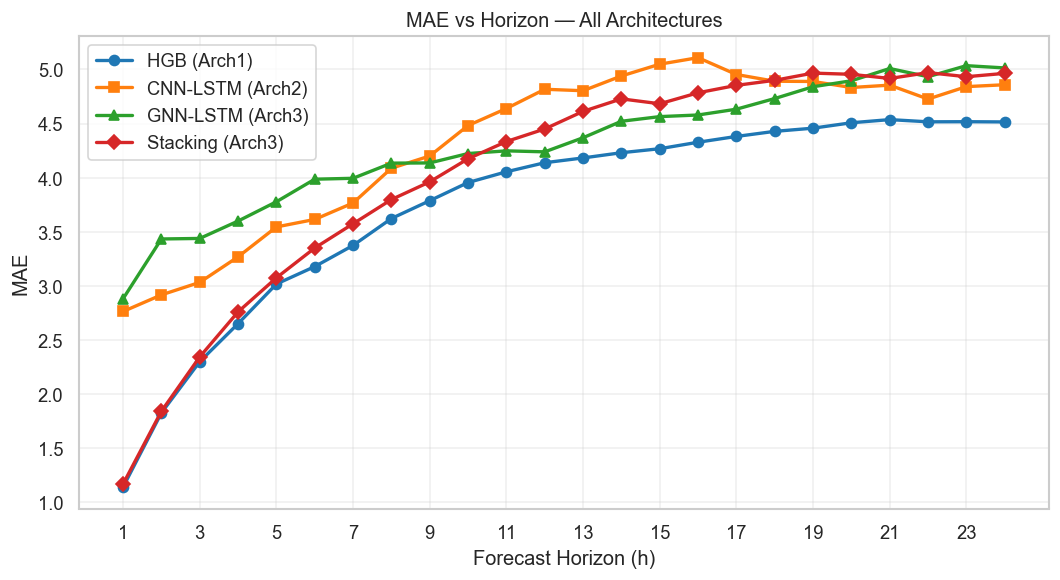

16:18:55 | src.evaluation | INFO | Saved figure: D:\MOJE\DATA_SCIENCE\ML_WARSAW_AQI_TOY\warsaw_aq_forecast\outputs\figures\all_architectures_r2.png


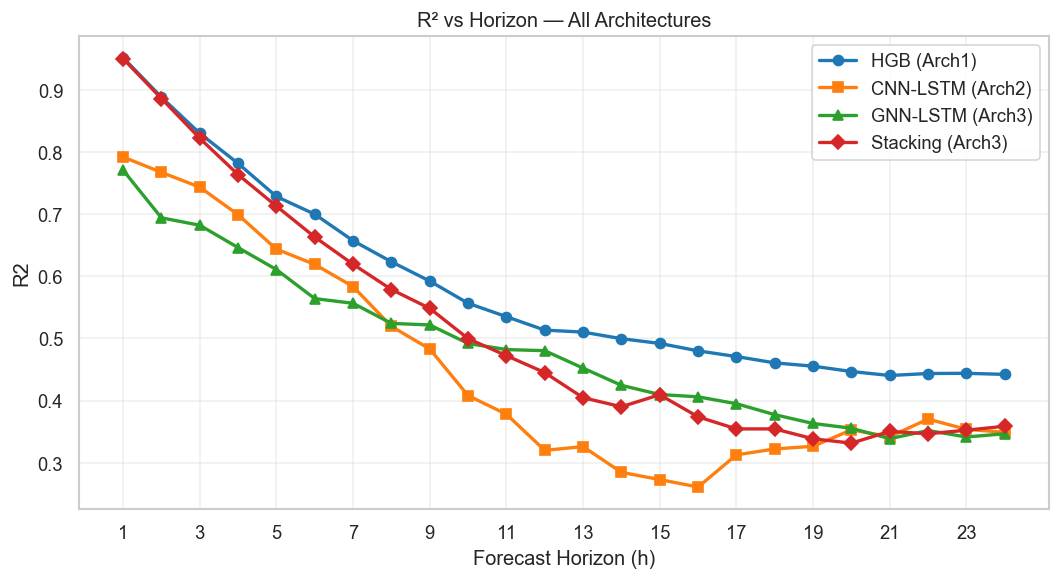

In [10]:
all_arch_results = {}

# Load Arch1 & Arch2 results
for fname, label in [('arch1_metrics.csv', 'HGB (Arch1)'), ('arch2_metrics.csv', 'CNN-LSTM (Arch2)')]:
    path = RESULTS_DIR / fname
    if path.exists():
        df_r = pd.read_csv(path)
        model_col = 'Model'
        first_model = df_r[model_col].iloc[0]
        sub = df_r[df_r[model_col] == first_model]
        all_arch_results[label] = {int(row['Horizon']): {'MAE': row['MAE'], 'RMSE': row['RMSE'],
                                                          'R2': row['R2'], 'MBE': row['MBE'],
                                                          'IA': row['IA']}
                                    for _, row in sub.iterrows()}

all_arch_results['GNN-LSTM (Arch3)'] = results_gnn
all_arch_results['Stacking (Arch3)'] = results_stack

fig = plot_horizon_metrics(all_arch_results, metric='MAE',
                            save_path=FIGURES_DIR / 'all_architectures_mae.png')
plt.title('MAE vs Horizon — All Architectures')
plt.show()

fig = plot_horizon_metrics(all_arch_results, metric='R2',
                            save_path=FIGURES_DIR / 'all_architectures_r2.png')
plt.title('R² vs Horizon — All Architectures')
plt.show()

## 9. Winter 2024 Time-Series Overlay

16:18:55 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=current
16:18:55 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:18:55 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:18:55 | src.feature_engineering | INFO |   X: (7766, 45) | y mean=12.60, y std=8.39
16:18:55 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=current
16:18:55 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:18:55 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns
16:18:55 | src.feature_engineering | INFO |   X: (38057, 45) | y mean=17.38, y std=12.67
16:18:56 | src.feature_engineering | INFO | build_feature_matrix | horizon=24 | weather_mode=current
16:18:56 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols
16:18

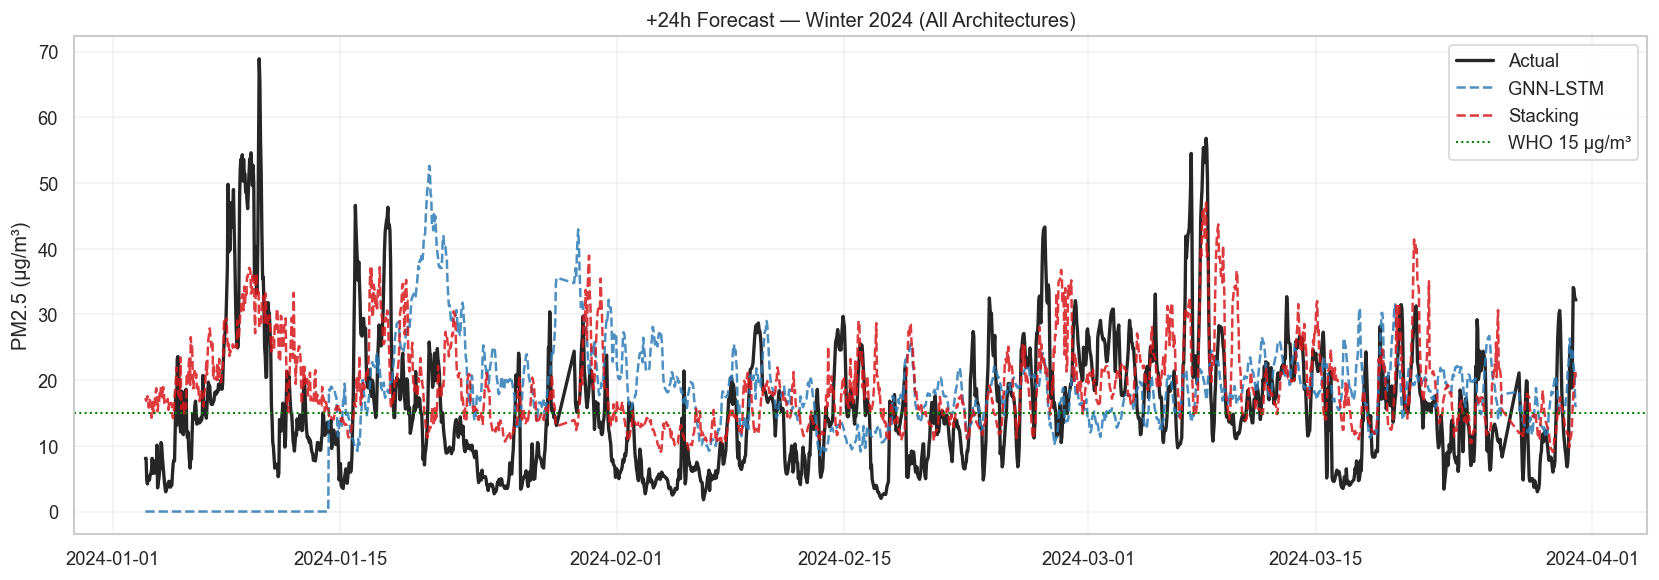

In [11]:
# Use h=24 for all models
X_te_24, y_te_24 = build_feature_matrix(test_df, horizon=24)

predictions_winter = {}

# GNN at h=24
n_tab = len(X_te_24)
gnn_pred_24 = np.zeros(n_tab)
n_gnn = len(gnn_preds)
if n_gnn >= n_tab:
    gnn_pred_24 = gnn_preds[-n_tab:, 23]
else:
    gnn_pred_24[-n_gnn:] = gnn_preds[:, 23]
predictions_winter['GNN-LSTM'] = gnn_pred_24

# Stacking at h=24
stack_pred_24 = []
for name, factory in base_model_classes.items():
    X_tr_24, y_tr_24 = build_feature_matrix(train_df, horizon=24)
    m = factory()
    m.fit(X_tr_24.values, y_tr_24.values)
    stack_pred_24.append(m.predict(X_te_24.values))
stack_pred_24.append(gnn_pred_24)
meta_feats_24 = X_te_24[meta_feature_cols].values if meta_feature_cols else np.zeros((n_tab, 1))
predictions_winter['Stacking'] = predict_stacking(stack_models[24], np.column_stack(stack_pred_24), meta_feats_24)

# Winter 2024 zoom
winter_mask = (y_te_24.index >= '2024-01-01') & (y_te_24.index <= '2024-03-31')
y_winter = y_te_24[winter_mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_winter.index, y_winter.values, label='Actual', linewidth=2, color='black', alpha=0.85)
colors = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']
for ci, (name, preds) in enumerate(predictions_winter.items()):
    pred_series = pd.Series(preds, index=y_te_24.index)[winter_mask]
    ax.plot(pred_series.index, pred_series.values, label=name,
            linewidth=1.5, linestyle='--', color=colors[ci % len(colors)], alpha=0.85)

from src.config import WHO_24H_PM25
ax.axhline(WHO_24H_PM25, color='green', linestyle=':', linewidth=1.2, label=f'WHO {WHO_24H_PM25} µg/m³')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('+24h Forecast — Winter 2024 (All Architectures)')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'arch3_winter2024_overlay.png', bbox_inches='tight')
plt.show()

## 10. Smog Episode Analysis
Identify the 5 worst PM2.5 episodes in the 2024 test set and examine how each model performed.

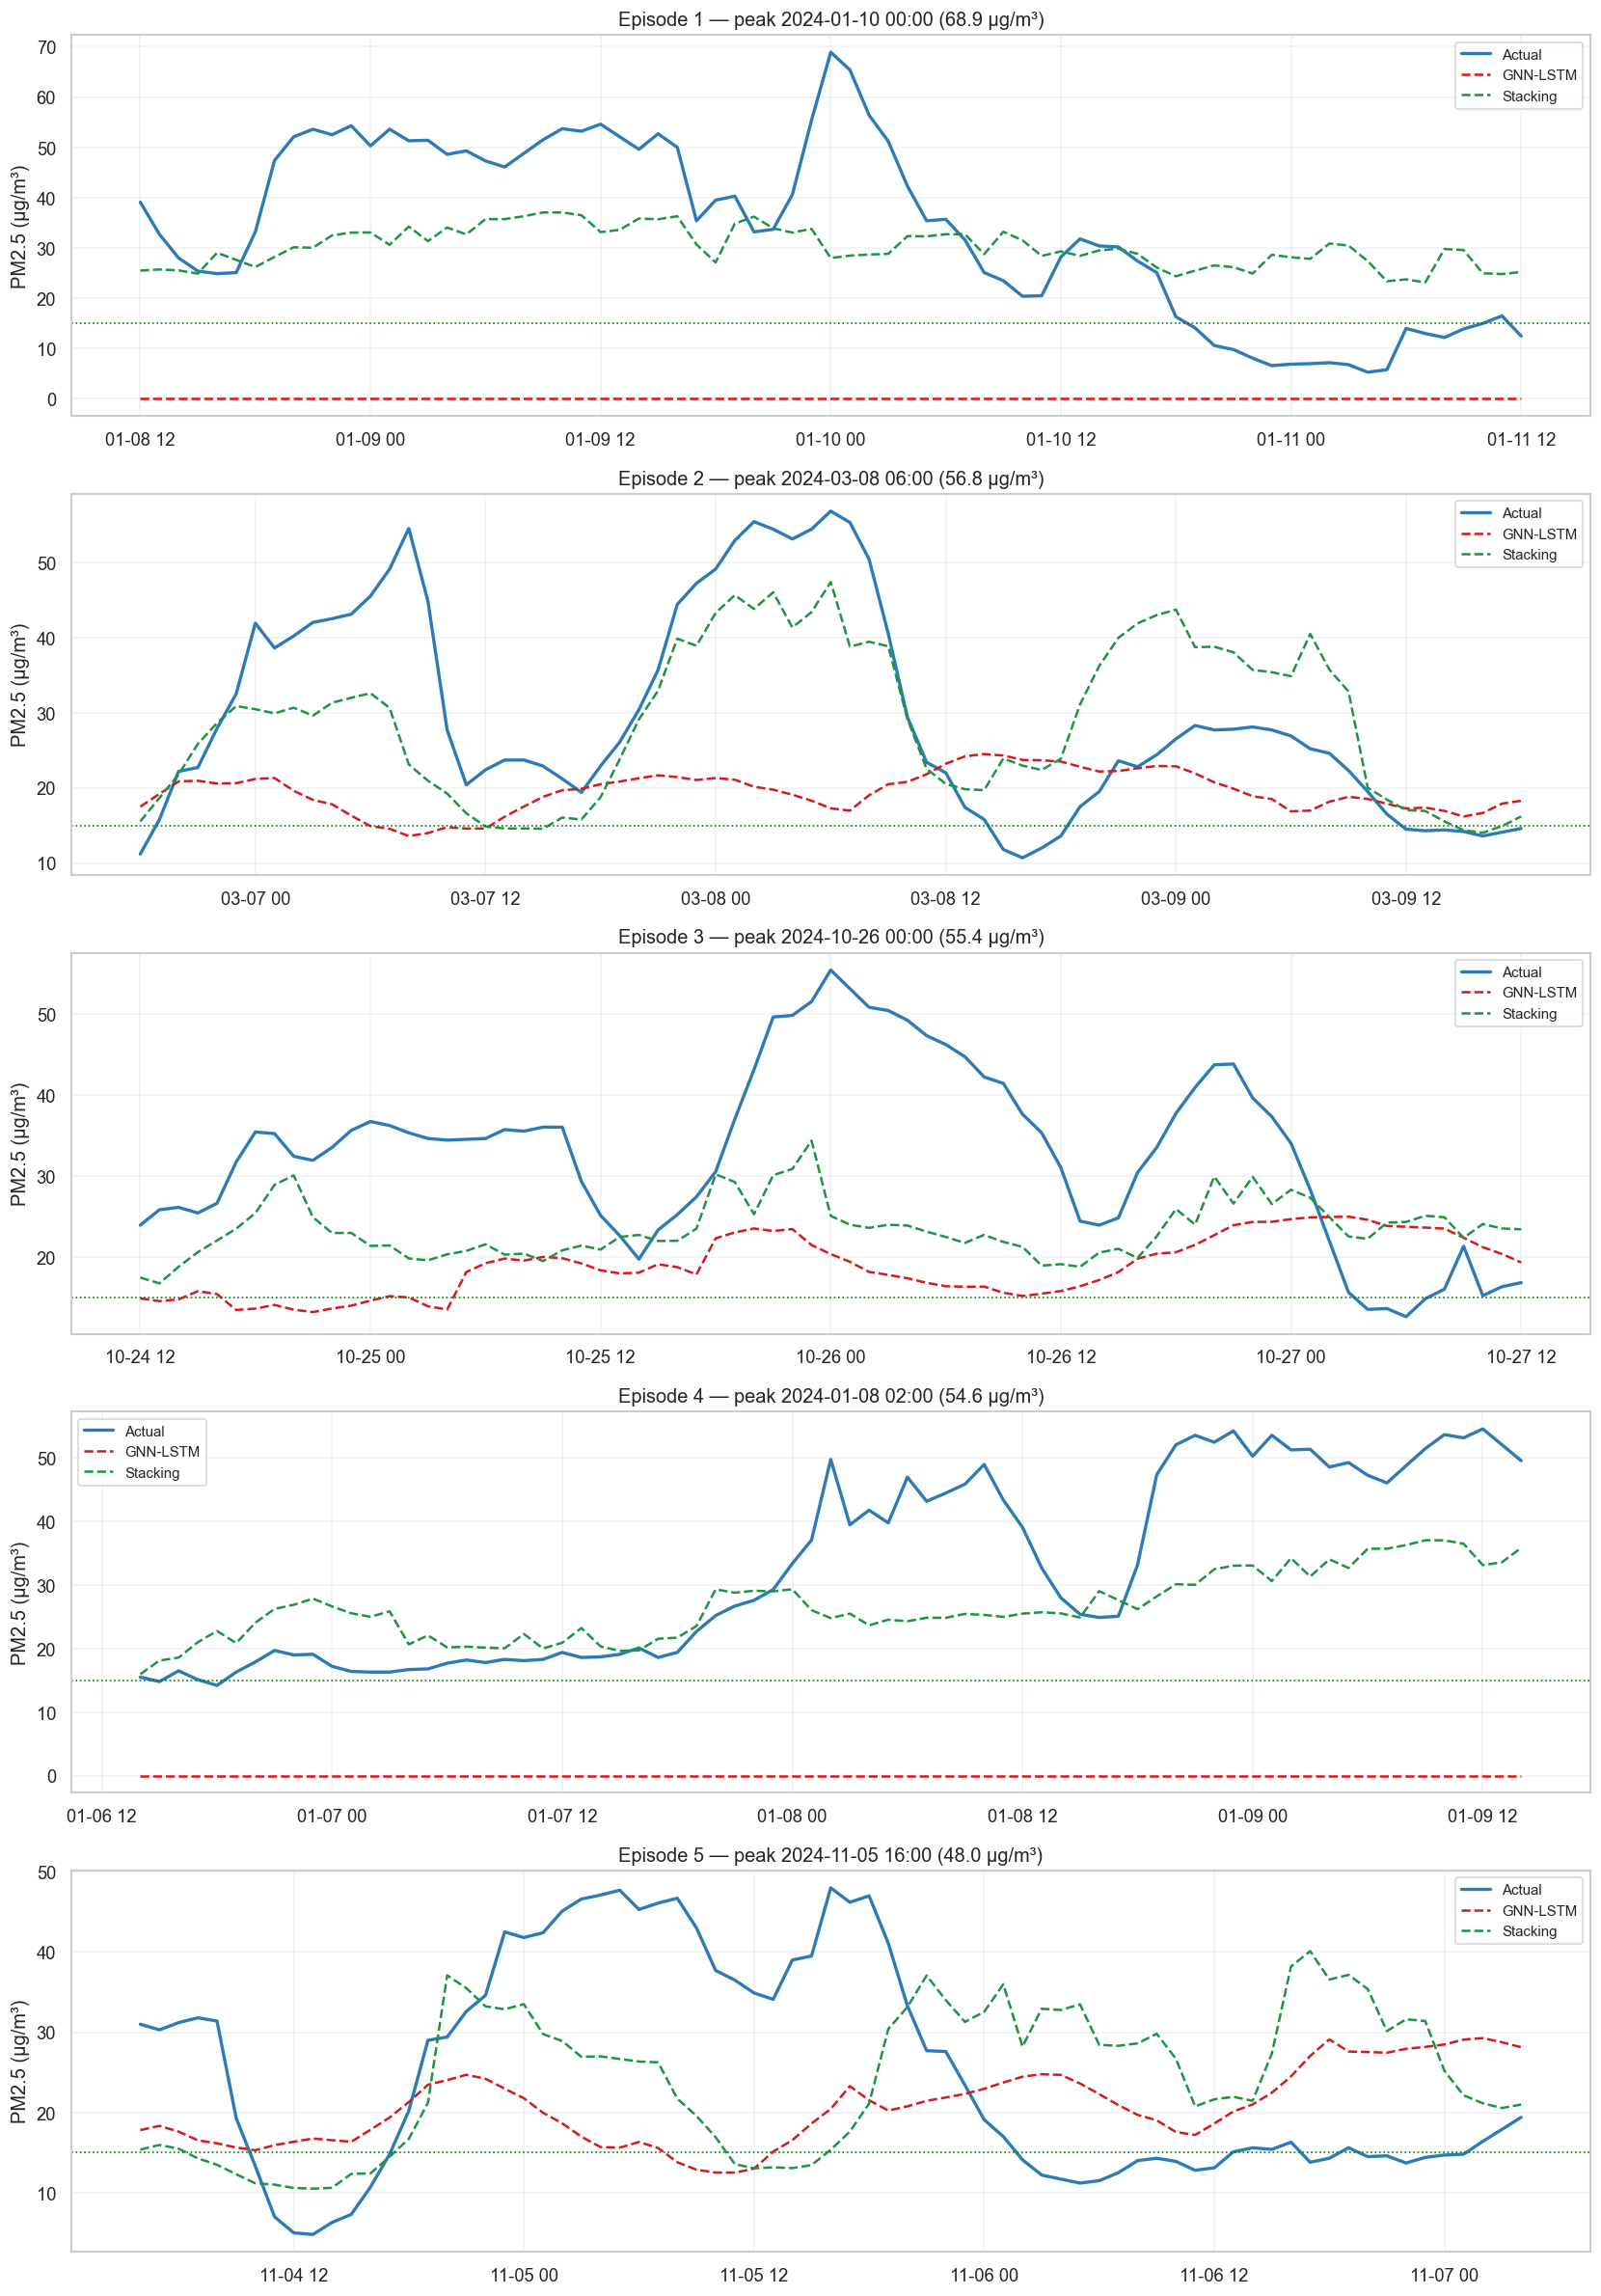

In [12]:
from src.evaluation import plot_smog_episodes

fig = plot_smog_episodes(
    y_te_24,
    predictions_winter,
    n_episodes=5,
    save_path=FIGURES_DIR / 'arch3_smog_episodes.png'
)
plt.show()

## 11. Final Comparison Table and Results Export

In [13]:
# Save Arch3 metrics
rows = []
for model_name, h_results in [('Arch3_GNN_LSTM', results_gnn), ('Arch3_Stacking', results_stack)]:
    for h, metrics in h_results.items():
        rows.append({'Model': model_name, 'Horizon': h, **metrics})

arch3_df = pd.DataFrame(rows)
arch3_df.to_csv(RESULTS_DIR / 'arch3_metrics.csv', index=False)

# Merge all results
all_dfs = []
for fname in ['arch1_metrics.csv', 'arch2_metrics.csv', 'arch3_metrics.csv']:
    p = RESULTS_DIR / fname
    if p.exists():
        all_dfs.append(pd.read_csv(p))

if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    final_df.to_csv(RESULTS_DIR / 'comparison_table.csv', index=False)
    print('Saved comparison_table.csv')

    # LaTeX-style key horizon table
    key = final_df[final_df['Horizon'].isin([1, 6, 12, 24])]
    print('\nKey horizons comparison:')
    print(key.pivot_table(index='Model', columns='Horizon',
                          values='MAE').round(3).to_string())

Saved comparison_table.csv

Key horizons comparison:
Horizon            1      6      12     24
Model                                     
Arch1_HGB       1.135  3.146  4.068  4.499
Arch1_XGBoost   1.143  3.179  4.138  4.515
Arch2_CNN_LSTM  2.764  3.615  4.817  4.859
Arch3_GNN_LSTM  2.882  3.986  4.239  5.014
Arch3_Stacking  1.171  3.351  4.450  4.964
